Trabalho realizado por Arthur Zoccarato e Pedro Teruo, coordenado pelo Professor Maicon Ribeiro

# Questão 1

## Dados do problema

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
t_vals = [0.98765431, 0.98765432, 0.98765433,
          0.98765434, 0.98765435, 0.98765436,
          0.98765437, 0.98765438, 0.98765439]
y = np.array([2.1, 2.1, 2.1, 2.0, 1.9, 1.9, 1.8, 1.7, 1.7])

### item a)

In [ ]:
# 1. Criar vetores coluna manualmente
# Cria um array de 1s do mesmo tamanho que t
coluna_1 = np.ones(len(t_vals))
coluna_2 = np.array(t_vals)

# 2. Montar a Matriz A
# np.column_stack junta arrays como colunas de uma matriz
A = np.column_stack((coluna_1, coluna_2))
print("Matriz A:")
print(A)

# 3. Usando numpy para obter o número de condição de A
cond_A = np.linalg.cond(A)
print("Número de condição da matriz A:", cond_A)

# 4. Usando numpy para obter a solução de quadrados mínimos com QR de modo similar ao A\b do MATLAB
x_qr, d, rank, s = np.linalg.lstsq(A, y, rcond=None)
print(f"Solução (QR/quadmin): {x_qr}")

# 5. Calculando a norma do resíduo (||r|| = ||Ax - y||)
residuo = np.linalg.norm(A @ x_qr - y)
print(f"Norma do resíduo: {residuo}")

Matriz A:
[[1.         0.98765431]
 [1.         0.98765432]
 [1.         0.98765433]
 [1.         0.98765434]
 [1.         0.98765435]
 [1.         0.98765436]
 [1.         0.98765437]
 [1.         0.98765438]
 [1.         0.98765439]]
Número de condição da matriz A: 76509279.92463098
Solução (QR/quadmin): [ 5761318.95808835 -5833333.32746028]
Norma do resíduo: 0.10671873731478902


### item b)

In [ ]:

# 1. Obtendo as equações normais (A^T A)x = A^T y
AtA = A.T @ A
Aty = A.T @ y
print("As equações normais são:")
print(f"(A^T A) =\n{AtA}")
print(f"(A^T y) =\n{Aty}")

# 2. Usando numpy para obter o número de condição de A^T A
cond_AtA = np.linalg.cond(AtA)
print(f"Número de condição da matriz dos coeficientes é: {cond_AtA}")

# 3. Usando Cholesky para resolver as equações normais
L = np.linalg.cholesky(AtA)
def substituicao_direta(L, b):
    n = L.shape[0]
    y_fs = np.zeros_like(b, dtype=float)
    for i in range(n):
        y_fs[i] = (b[i] - np.dot(L[i, :i], y_fs[:i])) / L[i, i]
    return y_fs

def retro_substituicao(U, b):
    n = U.shape[0]
    x_bs = np.zeros_like(b, dtype=float)
    for i in range(n - 1, -1, -1):
        x_bs[i] = (b[i] - np.dot(U[i, i + 1:], x_bs[i + 1:])) / U[i, i]
    return x_bs

y_inter = substituicao_direta(L, Aty)       # Ly = A^T y
x_normais = retro_substituicao(L.T, y_inter)  # L^T x = y
print(f"Solução (Cholesky + substituição): {x_normais}")

# 4. Calculando a norma do resíduo para as equações normais
residuo_normais = np.linalg.norm(A @ x_normais - y)
print(f"Norma do resíduo (Equações Normais): {residuo_normais}")

As equações normais são:
(A^T A) =
[[9.         8.88888915]
 [8.88888915 8.77915004]]
(A^T y) =
[17.3        17.08642022]
Número de condição da matriz dos coeficientes é: 4689146166474148.0
Solução (Cholesky + substituição): [ 3892001.64148798 -3940649.6       ]
Norma do resíduo (Equações Normais): 0.18133504678731074


### item c)


Comparação das soluções:
Solução (QR/quadmin): [ 5761318.95808835 -5833333.32746028]
Solução (Cholesky + substituição): [ 3892001.64148798 -3940649.6       ]


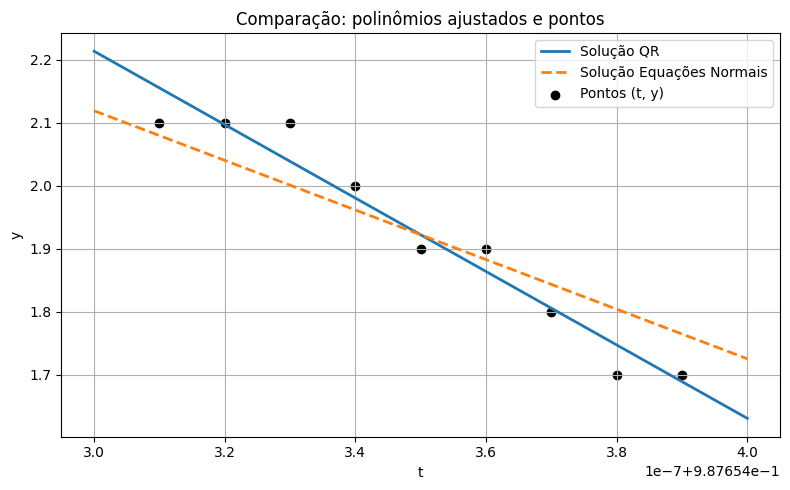

In [ ]:
# Comparando as soluções
print("\nComparação das soluções:")

print(f"Solução (QR/quadmin): {x_qr}")
print(f"Solução (Cholesky + substituição): {x_normais}")

# Verificando a diferença entre as soluções visualmente (polinomios)
t_plot = np.linspace(min(t_vals) - 1e-8, max(t_vals) + 1e-8, 300)  # grade fina no intervalo dos dados

def preenchimento_poli(coeffs, t):
    t = np.asarray(t)
    y = np.zeros_like(t, dtype=float)
    for i, c in enumerate(coeffs):
        y += c * t**i
    return y

y_qr_plot = preenchimento_poli(x_qr, t_plot)
y_normais_plot = preenchimento_poli(x_normais, t_plot)

plt.figure(figsize=(8,5))
plt.plot(t_plot, y_qr_plot, label='Solução QR', color='C0', linewidth=2)
plt.plot(t_plot, y_normais_plot, label='Solução Equações Normais', color='C1', linestyle='--', linewidth=2)
plt.scatter(t_vals, y, color='k', label='Pontos (t, y)')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Comparação: polinômios ajustados e pontos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### item d)

In [ ]:
# 1. Criar vetores coluna manualmente
# Cria uma coluna com os valores de t multiplicados por 3*(10^7)*(t - 0.98765435)
t_arr = np.array(t_vals, dtype=float)
coluna_3 = t_arr * (3 * 10**7) * (t_arr - 0.98765435)

# 2. Montar a Matriz Â
# np.column_stack junta arrays como colunas de uma matriz
Â = np.column_stack((coluna_1, coluna_3))
print("Matriz Â:")
print(Â)

# 3. Usando numpy para obter o número de condição de Â
cond_Â = np.linalg.cond(Â)
print("Número de condição da matriz Â:", cond_Â)

# 4. Usando numpy para obter a solução de quadrados mínimos com QR de modo similar ao A\b do MATLAB
x_qr_novo, d, rank, s = np.linalg.lstsq(Â, y, rcond=None)
print(f"Solução (QR/quadmin) com nova matriz: {x_qr_novo}")

# 5. Calculando a norma do resíduo (||r|| = ||Âx - y||)
residuo_novo = np.linalg.norm(Â @ x_qr_novo - y)
print(f"Norma do resíduo com nova matriz: {residuo_novo}")

Matriz Â:
[[ 1.         -1.18518517]
 [ 1.         -0.88888889]
 [ 1.         -0.5925926 ]
 [ 1.         -0.2962963 ]
 [ 1.          0.        ]
 [ 1.          0.29629631]
 [ 1.          0.59259262]
 [ 1.          0.88888894]
 [ 1.          1.18518527]]
Número de condição da matriz Â: 1.3071318409104187
Solução (QR/quadmin) com nova matriz: [ 1.92222223 -0.19687499]
Norma do resíduo com nova matriz: 0.10671873235825596


### item e)

In [ ]:
# 1. Obtendo as equações normais (Â^T Â)x = Â^T y
AtA_novo = Â.T @ Â
Aty_novo = Â.T @ y
print("As equações normais com nova matriz são:")
print(f"(Â^T Â) =\n{AtA_novo}")
print(f"(Â^T y) =\n{Aty_novo}")

# 2. Usando numpy para obter o número de condição de Â^T Â
cond_AtA_novo = np.linalg.cond(AtA_novo)
print(f"Número de condição da matriz dos coeficientes é: {cond_AtA_novo}")

# 3. Usando Cholesky para resolver as equações normais
L_novo = np.linalg.cholesky(AtA_novo)
y_inter_novo = substituicao_direta(L_novo, Aty_novo)       # Ly = Â^T y
x_normais_novo = retro_substituicao(L_novo.T, y_inter_novo)  # L^T x = y
print(f"Solução (Cholesky + substituição) com nova matriz: {x_normais_novo}")

# 4. Calculando a norma do resíduo para as equações normais
residuo_normais_novo = np.linalg.norm(Â @ x_normais_novo - y)
print(f"Norma do resíduo (Equações Normais) com nova matriz: {residuo_normais_novo}")

As equações normais com nova matriz são:
(Â^T Â) =
[[9.00000000e+00 1.76710450e-07]
 [1.76710450e-07 5.26749002e+00]]
(Â^T y) =
[17.3        -1.03703673]
Número de condição da matriz dos coeficientes é: 1.7085936495218599
Solução (Cholesky + substituição) com nova matriz: [ 1.92222223 -0.19687499]
Norma do resíduo (Equações Normais) com nova matriz: 0.10671873235825584


### item f)

Os polinômios são dados por:
$$P(t) = x_0 \cdot \phi_1(t) + x_1 \cdot \phi_2(t)$$

em que os coeficientes são os valores do vetor x de cada solução.

Perceba que as soluções dos itens d) e e) são idênticas até a precisão da máquina (~15 casas decimais) porque a nova base é ortogonal e bem condicionada ($\kappa \approx 1$). Isso elimina a instabilidade numérica vista anteriormente nas Equações Normais.

Adaptando o polinômio para a base dos itens d) e e), temos:

$$P(t) = 1.92222223 \cdot (1) + (-0.19687499) \cdot [3 \cdot 10^7 \cdot (t - 0.98765435)]$$

Visualmente, esta linha é idêntica àquela calculada pela decomposição QR no item a). A diferença fundamental é que, ao mudar a base para centralizar e escalar os dados, tornamos o método das Equações Normais (via Cholesky) tão preciso e robusto quanto o método QR, algo que era impossível com a base original mal condicionada.

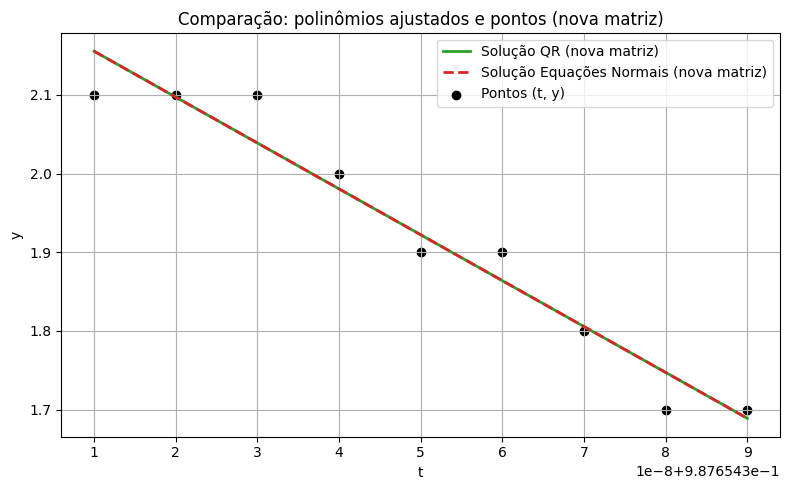

In [ ]:
# Verificando a diferença entre as soluções visualmente (polinomios)
y_qr_novo_plot = Â @ x_qr_novo
y_normais_novo_plot = Â @ x_normais_novo
plt.figure(figsize=(8,5))
plt.plot(t_vals, y_qr_novo_plot, label='Solução QR (nova matriz)', color='C2', linewidth=2)
plt.plot(t_vals, y_normais_novo_plot, label='Solução Equações Normais (nova matriz)', color='C3', linestyle='--', linewidth=2)
plt.scatter(t_vals, y, color='k', label='Pontos (t, y)')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Comparação: polinômios ajustados e pontos (nova matriz)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Questão 2

## item a)

In [ ]:
import numpy as np

A = np.array([[8.0, 1.0],
              [-2.0, 1.0]])

rho = 8.0

def potencia_inversa(A, rho, q0, max_iter=10, tol=1e-12, retornar_historico=False):
    A = np.array(A, dtype=float)
    q = np.array(q0, dtype=float)
    M = A - rho * np.eye(A.shape[0])

    lam = None  # autovalor
    q_antigo = None
    historico = []

    for k in range(max_iter):
        q_novo = np.linalg.solve(M, q)
        s1 = q_novo[0]
        q = q_novo / s1

        historico.append(q.copy())

        lam = rho + 1.0 / s1

        print(f"iter {k+1}: q = {q}, lambda = {lam}")

        if q_antigo is not None and np.linalg.norm(q - q_antigo) < tol:
            break
        q_antigo = q.copy()

    if retornar_historico:
        return lam, q, historico
    return lam, q


# Primeira execução
q0 = np.array([1.0, 1.0])
lambda_approx, v_approx = potencia_inversa(A, rho, q0)

print("\n" + "="*60)
print("Autovalor aproximado:", lambda_approx)
print("Autovetor aproximado:", v_approx)

# Segunda execução com histórico
print("\n" + "="*60)
print("ANÁLISE DE CONVERGÊNCIA")
print("="*60)

q0 = np.array([1.0, 1.0])
lambda_approx, v_approx, historico = potencia_inversa(A, rho, q0, retornar_historico=True)

# ---- item (b): razões ||q_{j+1}-v|| / ||q_j-v|| ----
v = v_approx

# erros em cada iteração: ||q_j - v||
erros = [np.linalg.norm(q - v) for q in historico]

# razões r_j = erro_{j+1} / erro_j
razoes = [erros[j+1] / erros[j] for j in range(len(erros) - 1)]

print("\nErros em cada iteração:")
for i, erro in enumerate(erros):
    print(f"  Iteração {i+1}: {erro:.6e}")

print("\nRazões de convergência observadas:")
for i, razao in enumerate(razoes):
    print(f"  r_{i+1} = erro_{i+2}/erro_{i+1} = {razao:.6f}")

# ---- taxa teórica de convergência ----
autovalores, _ = np.linalg.eig(A)

# lambda1 = autovalor mais próximo de rho
idx1 = np.argmin(np.abs(autovalores - rho))
lambda1 = autovalores[idx1]
# lambda2 = o outro autovalor
lambda2 = autovalores[1 - idx1]

taxa_teorica = abs(lambda1 - rho) / abs(lambda2 - rho)

print("\n" + "="*60)
print("ANÁLISE TEÓRICA")
print("="*60)
print(f"Autovalores reais da matriz A: {autovalores}")
print(f"Autovalor mais próximo de ρ={rho}: λ₁ = {lambda1:.6f}")
print(f"Outro autovalor: λ₂ = {lambda2:.6f}")
print(f"\nTaxa teórica de convergência: |λ₁-ρ|/|λ₂-ρ| = {taxa_teorica:.6f}")
print(f"Razão média observada: {np.mean(razoes[2:]):.6f}")

#tomamos o autovetor final como verdadeiro para o erro

iter 1: q = [ 1.   -0.25], lambda = 7.75
iter 2: q = [ 1.        -0.2962963], lambda = 7.703703703703704
iter 3: q = [ 1.         -0.29834254], lambda = 7.701657458563536
iter 4: q = [ 1.         -0.29843364], lambda = 7.70156636438582
iter 5: q = [ 1.         -0.29843769], lambda = 7.7015623077869355
iter 6: q = [ 1.         -0.29843787], lambda = 7.7015621271362225
iter 7: q = [ 1.         -0.29843788], lambda = 7.701562119091379
iter 8: q = [ 1.         -0.29843788], lambda = 7.701562118733122
iter 9: q = [ 1.         -0.29843788], lambda = 7.701562118717168
iter 10: q = [ 1.         -0.29843788], lambda = 7.701562118716457

Autovalor aproximado: 7.701562118716457
Autovetor aproximado: [ 1.         -0.29843788]

ANÁLISE DE CONVERGÊNCIA
iter 1: q = [ 1.   -0.25], lambda = 7.75
iter 2: q = [ 1.        -0.2962963], lambda = 7.703703703703704
iter 3: q = [ 1.         -0.29834254], lambda = 7.701657458563536
iter 4: q = [ 1.         -0.29843364], lambda = 7.70156636438582
iter 5: q = [ 1

# Questão 3

## Base para os 3 exemplos

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import time
from math import sin, pi

# Funções do Problema Físico
def g(x, y):
    """Condição de contorno"""
    if x == 0: return 0
    elif x == 1: return 0
    elif y == 0: return (x - 1) * np.sin(x)
    else: return x * (2 - x)

def f_func(x, y):
    """Fonte de calor (f(x,y) = 0 nesse problema)"""
    return 0

def initialize_grid(h):
    """Matriz inicial com as bordas preenchidas"""
    n = int(1/h) + 1
    u = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            # Contorno
            if i == 0 or i == n-1 or j == 0 or j == n-1:
                u[i, j] = g(i*h, j*h)
    return u

def create_convergence_table(results, method_name):
    """
    Cria uma tabela com os resultados de convergência
    """
    print("\n" + "="*70)
    print(f"TABELA DE RESULTADOS - {method_name}")
    print("="*70)
    print(f"{'h':<10} {'Dimensão':<15} {'Iterações':<15} {'Tempo (s)':<15}")
    print("-"*70)

    for r in results:
        print(f"{r['h_str']:<10} {r['matrix_dim']:<15} {r['iter']:<15} {r['time']:<15.2f}")

    print("="*70)

# item a)

In [ ]:
def solve_jacobi(h_vals, tol=1e-8, max_iter=300000):
    results = []

    for h in h_vals:
        n = int(1/h) + 1
        print(f"Jacobi: Calculando h = 1/{int(1/h)}...")
        u = initialize_grid(h)
        n = u.shape[0]
        h2 = h**2

        start = time.time()
        it = 0
        error = tol + 1.0

        # Matriz auxiliar para o novo passo
        u_new = u.copy()

        while error > tol and it < max_iter:
            u_old = u.copy() # Snapshot da iteração anterior

            # Loop pelos pontos internos
            for i in range(1, n-1):
                for j in range(1, n-1):
                    # Jacobi usa u_old para TODOS os vizinhos
                    u_new[i,j] = 0.25 * (u_old[i-1,j] + u_old[i+1,j] +
                                       u_old[i,j-1] + u_old[i,j+1] - h2*f_func(i*h, j*h))

            # Atualiza a matriz principal
            u = u_new.copy()

            # Cálculo do erro
            diff = np.linalg.norm(u - u_old)
            norm = np.linalg.norm(u)
            error = diff / norm if norm > 0 else 0
            it += 1
            # Mostra a iteração e o erro relativo a cada 1000 iterações
            if it % 1000 == 0:
              print(f"  Iteração {it}: erro relativo = {error:.2e}")

        elapsed = time.time() - start
        results.append({'h_str': f"1/{int(1/h)}", 'matrix_dim': (n-2)**2, 'u': u, 'iter': it, 'time': elapsed, 'error': error})

    return results

# Execução Item a)
h_values_a = [1/20, 1/40,1/80,1/160]
res_a = solve_jacobi(h_values_a)
create_convergence_table(res_a, "MÉTODO DE JACOBI")

Jacobi: Calculando h = 1/20...
  Iteração 1000: erro relativo = 1.87e-08
Jacobi: Calculando h = 1/40...
  Iteração 1000: erro relativo = 5.37e-05
  Iteração 2000: erro relativo = 2.43e-06
  Iteração 3000: erro relativo = 1.11e-07
Jacobi: Calculando h = 1/80...
  Iteração 1000: erro relativo = 2.32e-04
  Iteração 2000: erro relativo = 7.03e-05
  Iteração 3000: erro relativo = 3.02e-05
  Iteração 4000: erro relativo = 1.38e-05
  Iteração 5000: erro relativo = 6.35e-06
  Iteração 6000: erro relativo = 2.93e-06
  Iteração 7000: erro relativo = 1.35e-06
  Iteração 8000: erro relativo = 6.26e-07
  Iteração 9000: erro relativo = 2.89e-07
  Iteração 10000: erro relativo = 1.34e-07
  Iteração 11000: erro relativo = 6.19e-08
  Iteração 12000: erro relativo = 2.86e-08
  Iteração 13000: erro relativo = 1.32e-08
Jacobi: Calculando h = 1/160...
  Iteração 1000: erro relativo = 3.34e-04
  Iteração 2000: erro relativo = 1.53e-04
  Iteração 3000: erro relativo = 9.07e-05
  Iteração 4000: erro relativo 

## Item b)

In [ ]:
def solve_gauss_seidel(h_vals, tol=1e-8, max_iter=300000):
    results = []

    for h in h_vals:
        print(f"Gauss-Seidel: Calculando h = 1/{int(1/h)}...")
        u = initialize_grid(h)
        n = u.shape[0]
        h2 = h**2

        start = time.time()
        it = 0
        error = tol + 1.0

        while error > tol and it < max_iter:
            # Precisamos salvar o estado anterior APENAS para calcular o erro
            u_prev_iter = u.copy()

            for i in range(1, n-1):
                for j in range(1, n-1):
                    # Gauss-Seidel lê e escreve na MESMA matriz 'u'.
                    # u[i-1,j] e u[i,j-1] já são os valores novos desta iteração
                    u[i,j] = 0.25 * (u[i-1,j] + u[i+1,j] +
                                   u[i,j-1] + u[i,j+1] - h2*f_func(i*h, j*h))

            # Erro relativo
            diff = np.linalg.norm(u - u_prev_iter)
            norm = np.linalg.norm(u)
            error = diff / norm if norm > 0 else 0
            it += 1
            # Mostra a iteração e o erro relativo a cada 1000 iterações
            if it % 1000 == 0:
              print(f"  Iteração {it}: erro relativo = {error:.2e}")

        elapsed = time.time() - start
        results.append({'h_str': f"1/{int(1/h)}", 'matrix_dim': (n-2)**2, 'u': u, 'iter': it, 'time': elapsed, 'error': error})

    return results

# Execução Item b)
h_values_b = [1/20, 1/40,1/80,1/160]
res_b = solve_gauss_seidel(h_values_b)
create_convergence_table(res_b, "MÉTODO DEGAUSS-SEIDEL")

Gauss-Seidel: Calculando h = 1/20...
Gauss-Seidel: Calculando h = 1/40...
  Iteração 1000: erro relativo = 5.46e-06
  Iteração 2000: erro relativo = 1.14e-08
Gauss-Seidel: Calculando h = 1/80...
  Iteração 1000: erro relativo = 1.47e-04
  Iteração 2000: erro relativo = 2.92e-05
  Iteração 3000: erro relativo = 6.22e-06
  Iteração 4000: erro relativo = 1.33e-06
  Iteração 5000: erro relativo = 2.84e-07
  Iteração 6000: erro relativo = 6.07e-08
  Iteração 7000: erro relativo = 1.30e-08
Gauss-Seidel: Calculando h = 1/160...
  Iteração 1000: erro relativo = 3.11e-04
  Iteração 2000: erro relativo = 1.20e-04
  Iteração 3000: erro relativo = 6.10e-05
  Iteração 4000: erro relativo = 3.65e-05
  Iteração 5000: erro relativo = 2.36e-05
  Iteração 6000: erro relativo = 1.57e-05
  Iteração 7000: erro relativo = 1.06e-05
  Iteração 8000: erro relativo = 7.19e-06
  Iteração 9000: erro relativo = 4.88e-06
  Iteração 10000: erro relativo = 3.31e-06
  Iteração 11000: erro relativo = 2.25e-06
  Iteraçã

## Item c)

In [ ]:
def solve_one_sor(h, omega, tol=1e-8, max_iter=300000):
    """
    Roda UMA simulação SOR para um h e um omega específicos.
    Retorna o número de iterações.
    """
    # Se omega >= 2, SOR diverge teoricamente.
    if omega >= 2.0:
        return float('inf')

    u = initialize_grid(h)
    n = u.shape[0]
    h2 = h**2

    it = 0
    error = tol + 1.0

    # Loop de iteração
    while error > tol and it < max_iter:
        u_prev_iter = u.copy()

        for i in range(1, n-1):
            for j in range(1, n-1):
                # 1. Gauss-Seidel candidato
                val_gs = 0.25 * (u[i-1,j] + u[i+1,j] +
                               u[i,j-1] + u[i,j+1] - h2*f_func(i*h, j*h))

                # 2. Relaxação
                u[i,j] = (1 - omega) * u[i,j] + omega * val_gs

        # Otimização: Calcular erro apenas a cada 10 iterações para ganhar velocidade
        if it % 10 == 0:
            diff = np.linalg.norm(u - u_prev_iter)
            norm = np.linalg.norm(u)
            error = diff / norm if norm > 0 else 0

        it += 1

    if it >= max_iter:
        return float('inf') # Não convergiu

    return it

def run_sor_table_experiment():
    """
    Gera a tabela completa variando Omega e h
    """
    h_list = [1/20, 1/40,1/80]
    omega_list = [0.8, 1.0, 1.5, 1.8, 1.9, 1.95, 1.97, 2.0]

    # Cabeçalho da Tabela
    print("\n" + "="*60)
    print("TABELA DE RESULTADOS SOR (Iterações)")
    print("="*60)

    # Imprime cabeçalho das colunas (h)
    header = f"{'w \\ h':<8} |"
    for h in h_list:
        header += f" {'1/'+str(int(1/h)):<10}"
    print(header)
    print("-" * 60)

    # Loop principal (Linhas = Omegas)
    for w in omega_list:
        row_str = f"{w:<8.2f} |"

        # Loop interno (Colunas = h)
        for h in h_list:
            # Roda a simulação para este par (w, h)
            iter_count = solve_one_sor(h, w)

            # Formata o resultado
            if iter_count == float('inf'):
                val_str = "Inf"
            else:
                val_str = str(iter_count)

            row_str += f" {val_str:<10}"

        # Imprime a linha completa
        print(row_str)

    print("="*60)

# Execução item c)
if __name__ == "__main__":
    run_sor_table_experiment()


TABELA DE RESULTADOS SOR (Iterações)
w \ h    | 1/20       1/40       1/80      
------------------------------------------------------------
0.80     | 821        2931       10351     
1.00     | 571        2021       7171      
1.50     | 201        741        2651      
1.80     | 91         251        961       
1.90     | 181        181        451       
1.95     | 361        361        361       
1.97     | 591        591        611       
2.00     | Inf        Inf        Inf       
